Epoch 1/3, Loss: 124.9140
Epoch 2/3, Loss: 114.6166
Epoch 3/3, Loss: 101.6111


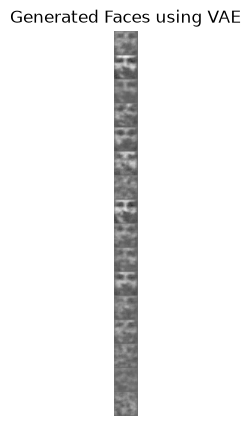

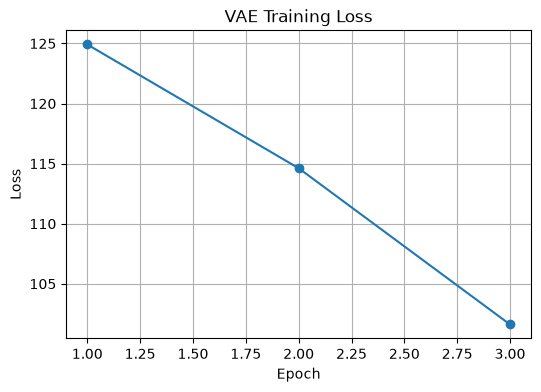

VAE image generation completed successfully.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = torch.tensor(faces.images[:200], dtype=torch.float32).unsqueeze(1)
loader = DataLoader(TensorDataset(X), batch_size=32, shuffle=True)

latent_dim = 16

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,32,4,2,1), nn.ReLU(),
            nn.Conv2d(32,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.ReLU()
        )
        self.mu = nn.Linear(128*8*8, latent_dim)
        self.logvar = nn.Linear(128*8*8, latent_dim)

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        return self.mu(x),self.logvar(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(latent_dim,128*8*8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1),nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1),nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,2,1),nn.Sigmoid()
        )

    def forward(self,z):
        x = self.fc(z)
        x = x.view(x.size(0),128,8,8)
        return self.deconv(x)

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self,mu,logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self,x):
        mu,logvar = self.encoder(x)
        z = self.reparameterize(mu,logvar)
        return self.decoder(z),mu,logvar

def loss_function(recon,x,mu,logvar):
    recon_loss = F.mse_loss(recon,x,reduction="sum")
    kl_loss = -0.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp())
    return recon_loss+kl_loss

model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

losses = []

for epoch in range(3):
    model.train()
    total_loss = 0

    for (images,) in loader:
        images = images.to(device)
        recon,mu,logvar = model(images)
        loss = loss_function(recon,images,mu,logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss/len(X)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/3, Loss: {avg_loss:.4f}")

model.eval()

with torch.no_grad():
    z = torch.randn(16,latent_dim).to(device)
    generated = model.decoder(z).cpu()

grid = torch.cat([generated[i] for i in range(16)],dim=1)

plt.figure(figsize=(10,5))
plt.imshow(grid.squeeze(),cmap="gray")
plt.axis("off")
plt.title("Generated Faces using VAE")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(range(1,4),losses,marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.grid(True)
plt.show()

print("VAE image generation completed successfully.")